In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')
 
     
wri = pd.read_csv("country_risk_features.csv") 
        

 
latest = wri[wri['year'] == wri['year'].max()].copy()
print(f"Working with {len(latest)} countries in year {wri['year'].max()}")
 
# Defensive column detection — handles naming differences between Phase 2 versions
def find_col(df, candidates):
    """Return the first column name from candidates that exists in df."""
    for c in candidates:
        if c in df.columns:
            return c
    return None
 
COL_COMPOUND_MULT = find_col(wri, ['compound_multiplier', 'compound_mult'])
COL_DIMS_ELEVATED = find_col(wri, ['risk_dimensions_elevated', 'risk_dims_elevated'])
 
if COL_COMPOUND_MULT is None:
    risk_cols = ['nhes', 'gss_risk', 'irs', 'efs', 'rsbs']
    wri['risk_dimensions_elevated'] = wri[risk_cols].apply(lambda r: (r > 50).sum(), axis=1)
    cmap_dict = {0: 1.0, 1: 1.0, 2: 1.1, 3: 1.25, 4: 1.5, 5: 1.8}
    wri['compound_multiplier'] = wri['risk_dimensions_elevated'].map(cmap_dict)
    COL_COMPOUND_MULT = 'compound_multiplier'
    COL_DIMS_ELEVATED = 'risk_dimensions_elevated'
    latest = wri[wri['year'] == wri['year'].max()].copy()
 
print(f"Compound multiplier col: {COL_COMPOUND_MULT}")
print(f"Dims elevated col:       {COL_DIMS_ELEVATED}")
 
# Shared constants used across all charts
RISK_COLORS = {
    'High': '#D32F2F', 'Medium-High': '#F57C00',
    'Medium-Low': '#66BB6A', 'Low': '#1976D2'
}
 
CHOKEPOINTS = {
    'EGY': 2.5, 'YEM': 2.0, 'DJI': 2.0, 'MYS': 1.5,
    'SGP': 1.5, 'PAN': 1.8, 'TUR': 1.5
}
 

Working with 193 countries in year 2025
Compound multiplier col: compound_multiplier
Dims elevated col:       risk_dimensions_elevated


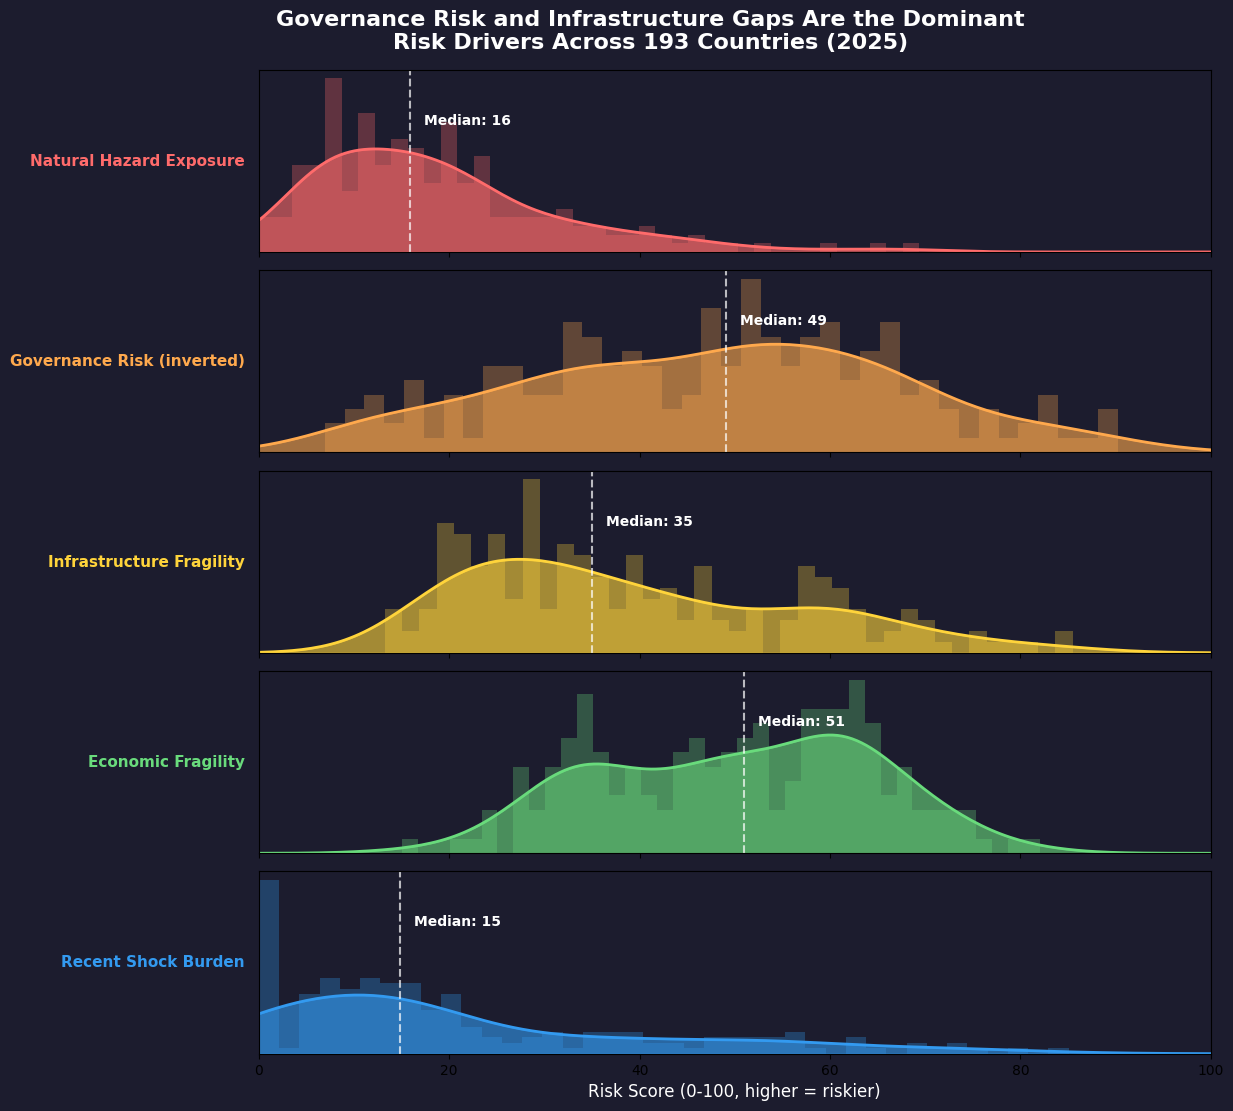

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# Dark background applied to figure and all subplots — needed for white text to be legible
fig.patch.set_facecolor('#1C1C2E')  # deep dark navy for the figure
for ax in axes:
    ax.set_facecolor('#1C1C2E')     # same dark background per subplot

fig.suptitle(
    'Governance Risk and Infrastructure Gaps Are the Dominant\n'
    'Risk Drivers Across 193 Countries (2025)',
    y=0.98, fontsize=16, fontweight='bold', color='white'  # now visible on dark bg
)

features = [
    ('nhes',     'Natural Hazard Exposure',       '#FF6B6B'),
    ('gss_risk', 'Governance Risk (inverted)',     '#FFA94D'),
    ('irs',      'Infrastructure Fragility',       '#FFD43B'),
    ('efs',      'Economic Fragility',             '#69DB7C'),
    ('rsbs',     'Recent Shock Burden',            '#339AF0'),
]

from scipy.stats import gaussian_kde  # moved out of the loop — no need to re-import each iteration

for i, (col, label, color) in enumerate(features):
    ax = axes[i]
    data = latest[col].dropna()

    ax.hist(data, bins=40, color=color, alpha=0.3, edgecolor='none', density=True)
    
    kde_x = np.linspace(0, 100, 200)
    try:
        kde = gaussian_kde(data)
        ax.fill_between(kde_x, kde(kde_x), alpha=0.6, color=color)
        ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)
    except:
        pass

    med = data.median()
    ax.axvline(med, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(med + 1.5, ax.get_ylim()[1] * 0.7, f'Median: {med:.0f}',
            color='white', fontsize=10, fontweight='bold')

    # Fix 2: Horizontal labels (rotation=0) aligned to the right of the label area
    # ha='right' anchors the text so it sits flush against the plot edge
    ax.set_ylabel(label, fontsize=11, fontweight='bold', color=color,
                  rotation=0, ha='right', va='center', labelpad=10)
    ax.set_yticks([])
    ax.set_xlim(0, 100)

axes[-1].set_xlabel('Risk Score (0-100, higher = riskier)', fontsize=12, color='white')

# Fix 2 continued: widen the left margin so the horizontal labels have room
# top=0.93 pulls the plot area down slightly to give the suptitle breathing room
plt.subplots_adjust(left=0.22, top=0.93, hspace=0.1)

plt.show()

<Axes: >

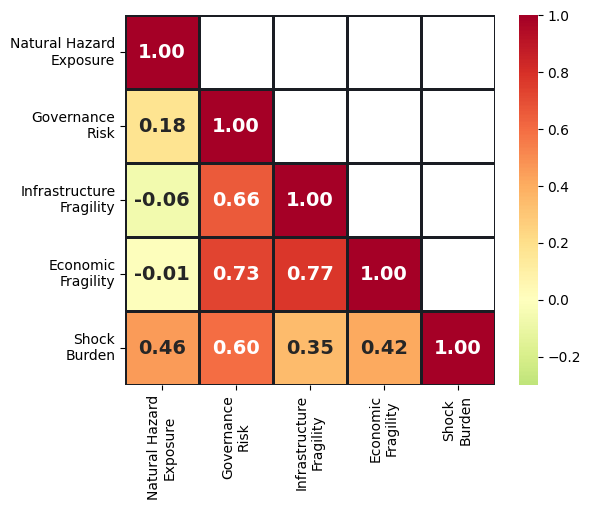

In [4]:
# Chart 2 — Correlation Heatmap of the Five Risk Dimensions
# Lower triangle only; checks whether dimensions are capturing independent signals
# or largely measuring the same underlying variation.
corr_cols = ['nhes', 'gss_risk', 'irs', 'efs', 'rsbs']
corr_labels = ['Natural Hazard\nExposure', 'Governance\nRisk',
               'Infrastructure\nFragility', 'Economic\nFragility', 'Shock\nBurden']
corr = latest[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, vmin=-0.3, vmax=1, square=True,
            linewidths=2, linecolor='#1A1D23',
            xticklabels=corr_labels, yticklabels=corr_labels,
            annot_kws={'size': 14, 'weight': 'bold'})

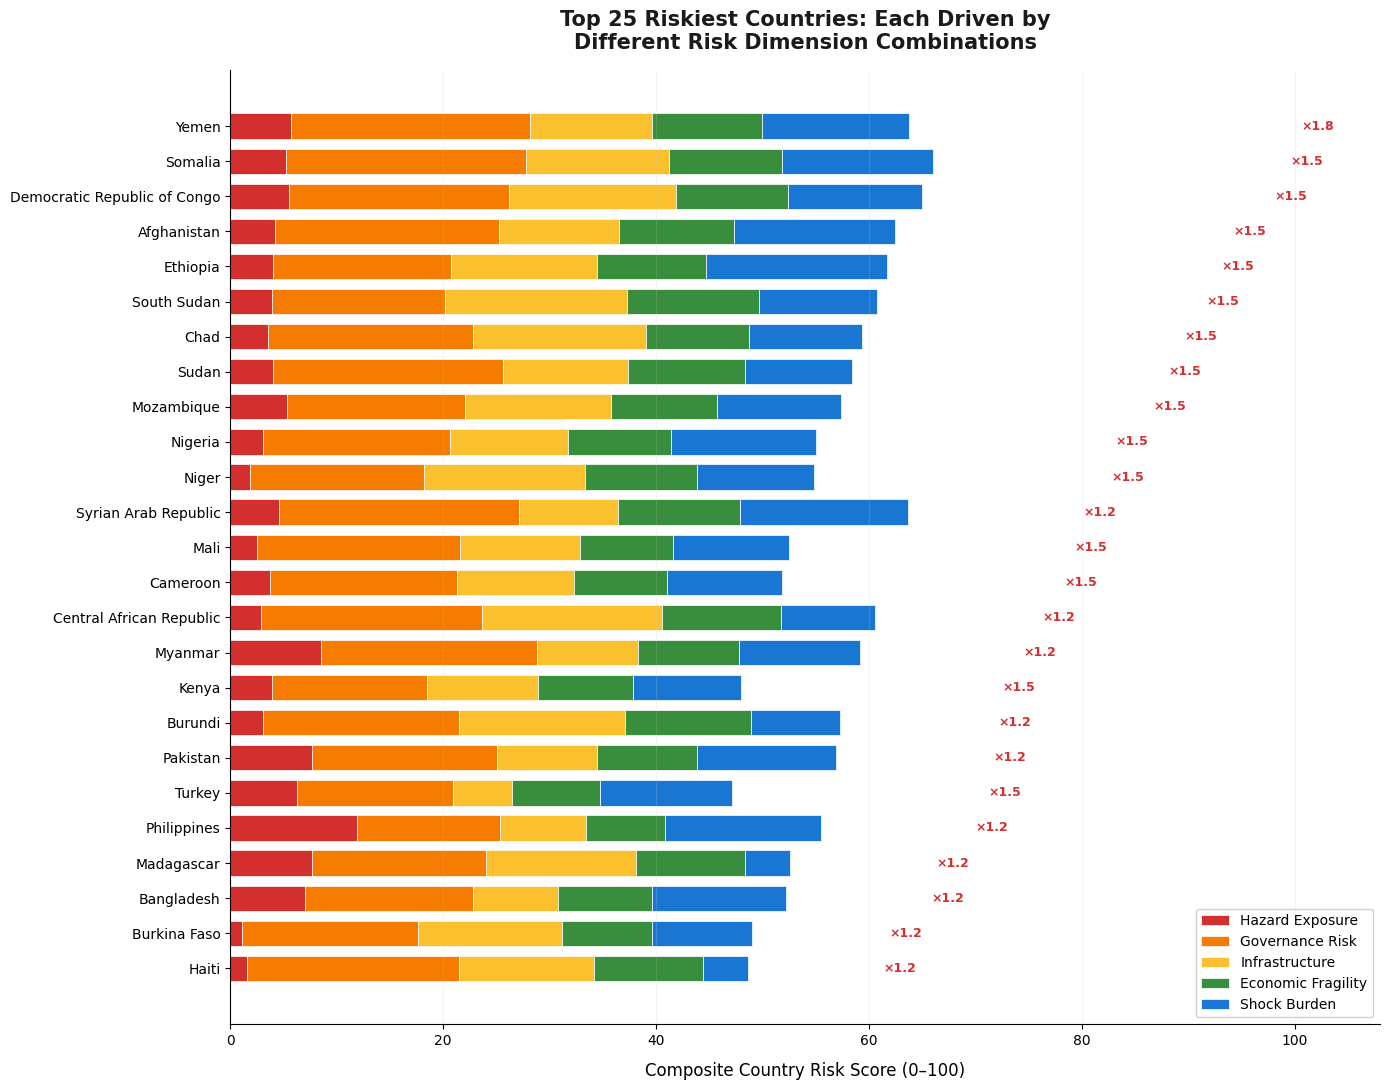

In [5]:
# Chart 3 — Top 25 Riskiest Countries: Stacked Dimension Breakdown
# Breaks each country's composite score into its five weighted components,
# showing which dimension is doing the most damage in each case.
 
fig, ax = plt.subplots(figsize=(14, 11))
 
top25 = latest.nlargest(25, 'ccrs_compound').sort_values('ccrs_compound')
y_pos = np.arange(len(top25))
 
weights = {'nhes': 0.20, 'gss_risk': 0.25, 'irs': 0.20, 'efs': 0.15, 'rsbs': 0.20}
colors_stack = ['#D32F2F', '#F57C00', '#FBC02D', '#388E3C', '#1976D2']
labels_stack = ['Hazard Exposure', 'Governance Risk', 'Infrastructure',
                'Economic Fragility', 'Shock Burden']
 
left = np.zeros(len(top25))
for (feat, w), color, label in zip(weights.items(), colors_stack, labels_stack):
    contribution = top25[feat].values * w
    ax.barh(y_pos, contribution, left=left, color=color, label=label,
            edgecolor='white', linewidth=0.5, height=0.72)
    left += contribution
 
for i, (_, row) in enumerate(top25.iterrows()):
    mult_val = row[COL_COMPOUND_MULT]
    if mult_val > 1.0:
        ax.text(row['ccrs_compound'] + 0.6, i, f'×{mult_val:.1f}',
                color='#D32F2F', fontsize=9, fontweight='bold', va='center')
 
ax.set_yticks(y_pos)
ax.set_yticklabels(top25['country'], fontsize=10)
ax.set_xlabel('Composite Country Risk Score (0–100)', fontsize=12, labelpad=10)
ax.set_title('Top 25 Riskiest Countries: Each Driven by\nDifferent Risk Dimension Combinations',
             fontsize=15, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9, edgecolor='#ccc')
ax.set_xlim(0, 108)
ax.grid(axis='x', alpha=0.2, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.show()

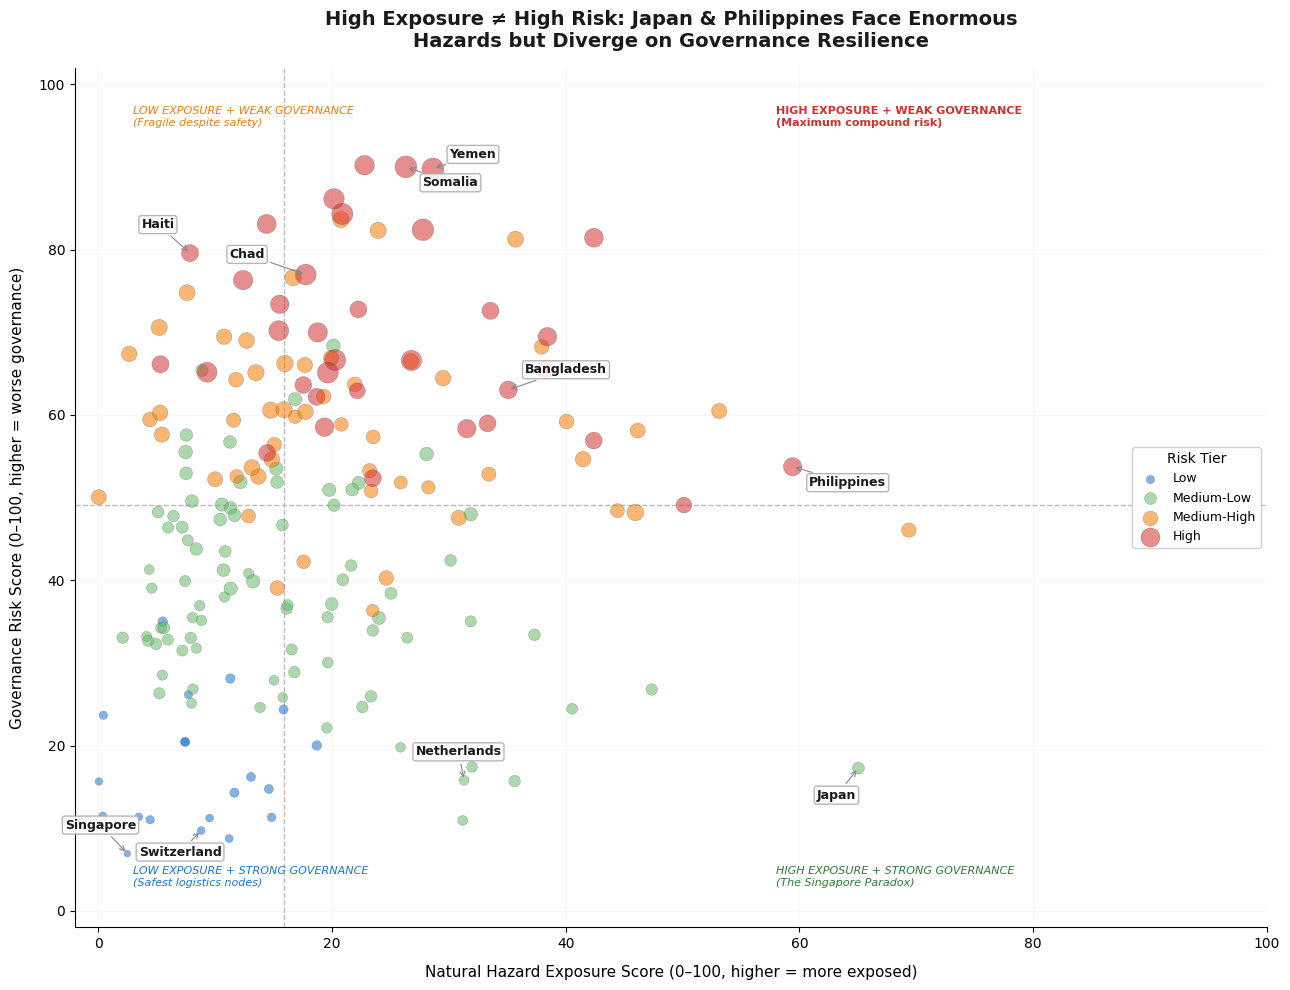

In [6]:
# Chart 4 — Natural Hazard Exposure vs Governance Risk
# The central analytical argument: physical hazard exposure and governance quality
# are nearly orthogonal axes. A country can be heavily exposed but well-governed
# (Japan, Singapore), or low-exposure but institutionally fragile (Sahel nations).
# Bubble size = composite risk score; quadrant labels identify each risk profile type.
 
fig, ax = plt.subplots(figsize=(13, 10))
 
tier_order = ['Low', 'Medium-Low', 'Medium-High', 'High']
for tier in tier_order:
    mask = latest['risk_tier'] == tier
    subset = latest[mask]
    ax.scatter(subset['nhes'], subset['gss_risk'],
               s=subset['ccrs_compound'] * 2.5,
               c=RISK_COLORS[tier], alpha=0.55, edgecolors='#555',
               linewidth=0.3, label=tier, zorder=3)
 
annotate_list = {
    'Singapore': (-45, 18), 'Japan': (-30, -22), 'Philippines': (12, -14),
    'Yemen': (12, 8), 'Somalia': (12, -14), 'Chad': (-55, 12),
    'Netherlands': (-35, 18), 'Bangladesh': (12, 12),
    'Switzerland': (-45, -18), 'Haiti': (-35, 18),
}
for country, offset in annotate_list.items():
    row = latest[latest['country'] == country]
    if len(row):
        ax.annotate(country, xy=(row['nhes'].values[0], row['gss_risk'].values[0]),
                    xytext=offset, textcoords='offset points',
                    fontsize=9, fontweight='bold', color='#1a1a1a',
                    arrowprops=dict(arrowstyle='->', color='#888', lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor='#aaa', alpha=0.85))
 
med_nhes = latest['nhes'].median()
med_gss = latest['gss_risk'].median()
ax.axvline(med_nhes, color='#bbb', linestyle='--', linewidth=1)
ax.axhline(med_gss, color='#bbb', linestyle='--', linewidth=1)
 
ax.text(3, 95, 'LOW EXPOSURE + WEAK GOVERNANCE\n(Fragile despite safety)',
        fontsize=8, color='#F57C00', fontstyle='italic')
ax.text(58, 95, 'HIGH EXPOSURE + WEAK GOVERNANCE\n(Maximum compound risk)',
        fontsize=8, color='#D32F2F', fontweight='bold')
ax.text(3, 3, 'LOW EXPOSURE + STRONG GOVERNANCE\n(Safest logistics nodes)',
        fontsize=8, color='#1976D2', fontstyle='italic')
ax.text(58, 3, 'HIGH EXPOSURE + STRONG GOVERNANCE\n(The Singapore Paradox)',
        fontsize=8, color='#2E7D32', fontstyle='italic')
 
ax.set_xlabel('Natural Hazard Exposure Score (0–100, higher = more exposed)',
              fontsize=11, labelpad=10)
ax.set_ylabel('Governance Risk Score (0–100, higher = worse governance)',
              fontsize=11, labelpad=10)
ax.set_title('High Exposure ≠ High Risk: Japan & Philippines Face Enormous\n'
             'Hazards but Diverge on Governance Resilience',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(title='Risk Tier', title_fontsize=10, fontsize=9, loc='center right',
          framealpha=0.9, edgecolor='#ccc')
ax.set_xlim(-2, 100)
ax.set_ylim(-2, 102)
ax.grid(alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.show()

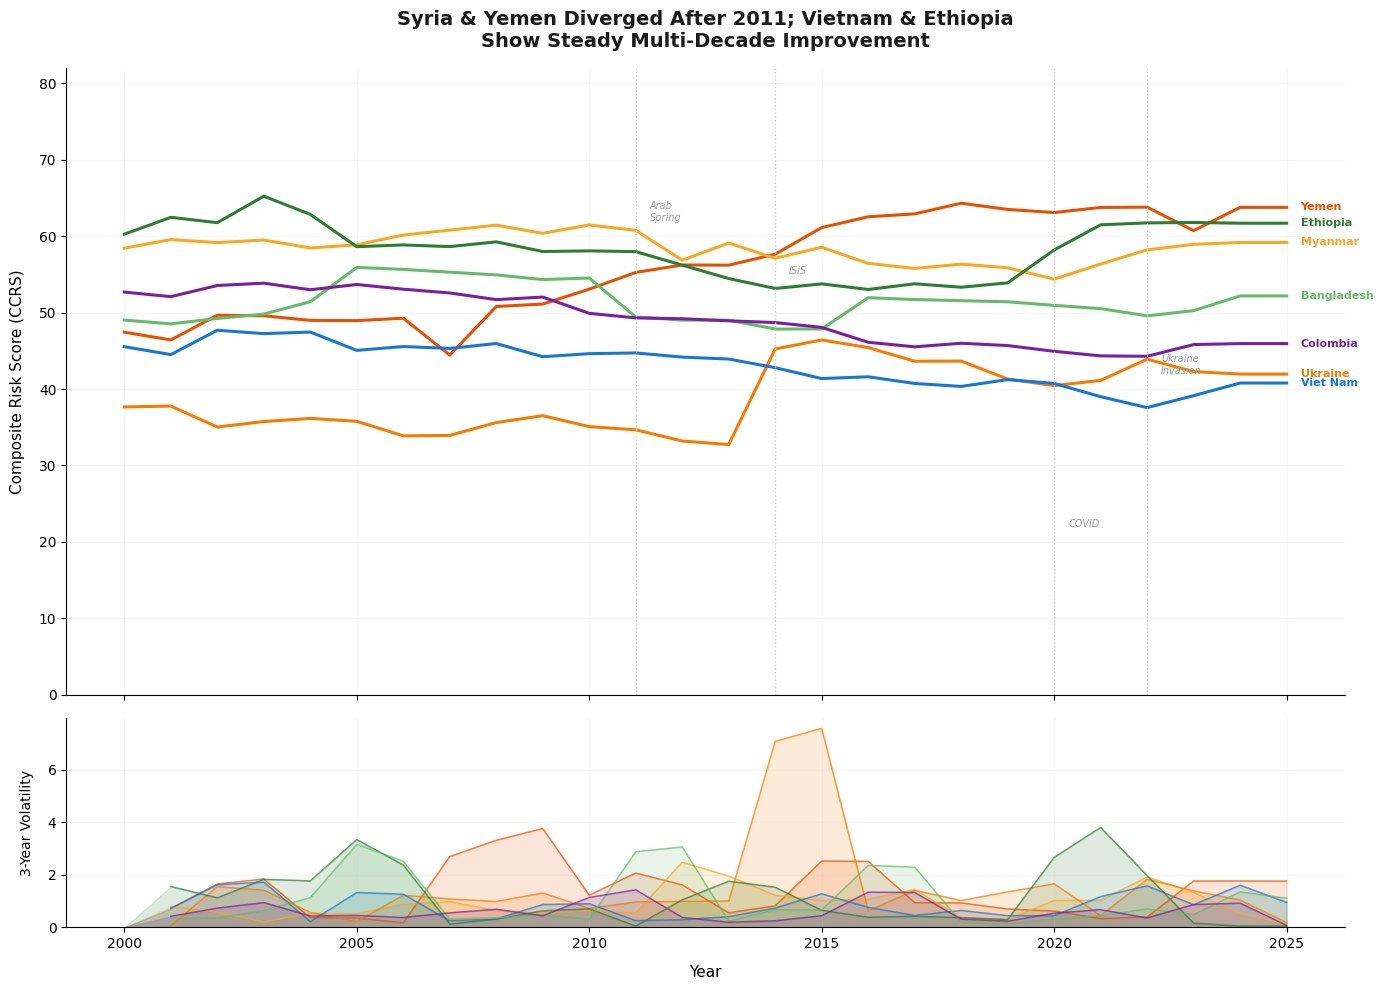

In [7]:
# Chart 5 — Risk Trajectories Over Time with Crisis Annotations
# Tracks selected countries from 2000–present alongside global crisis events.
# The bottom panel shows the annual average CCRS across all countries,
# making regional divergence visible against the global backdrop.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

track = {
    'Syria': '#D32F2F', 'Yemen': '#E65100', 'Myanmar': '#F9A825',
    'Ukraine': '#F57C00', 'Ethiopia': '#2E7D32',
    'Viet Nam': '#1976D2', 'Bangladesh': '#66BB6A', 'Colombia': '#7B1FA2',
}

for country, color in track.items():
    cd = wri[wri['country'] == country].sort_values('year')
    if len(cd):
        ax1.plot(cd['year'], cd['ccrs'], color=color, linewidth=2.2, label=country)
        last = cd.iloc[-1]
        ax1.text(last['year'] + 0.3, last['ccrs'], country, fontsize=8,
                 fontweight='bold', color=color, va='center')

crises = [(2011, 'Arab\nSpring', 62), (2014, 'ISIS', 55),
          (2020, 'COVID', 22), (2022, 'Ukraine\nInvasion', 42)]
for yr, label, yp in crises:
    ax1.axvline(yr, color='#ccc', linestyle=':', linewidth=1)
    ax1.text(yr + 0.3, yp, label, fontsize=7, color='#999', fontstyle='italic')

ax1.set_ylabel('Composite Risk Score (CCRS)', fontsize=11, labelpad=10)
ax1.set_title('Syria & Yemen Diverged After 2011; Vietnam & Ethiopia\n'
              'Show Steady Multi-Decade Improvement',
              fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax1.set_ylim(0, 82)
ax1.grid(alpha=0.15, color='#ccc')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for country, color in track.items():
    cd = wri[wri['country'] == country].sort_values('year')
    if len(cd):
        ax2.fill_between(cd['year'], 0, cd['ccrs_vol_3y'].fillna(0),
                         color=color, alpha=0.15)
        ax2.plot(cd['year'], cd['ccrs_vol_3y'], color=color,
                 linewidth=1.1, alpha=0.7)

ax2.set_ylabel('3-Year Volatility', fontsize=10, labelpad=10)
ax2.set_xlabel('Year', fontsize=11, labelpad=10)
ax2.set_ylim(0)
ax2.grid(alpha=0.15, color='#ccc')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

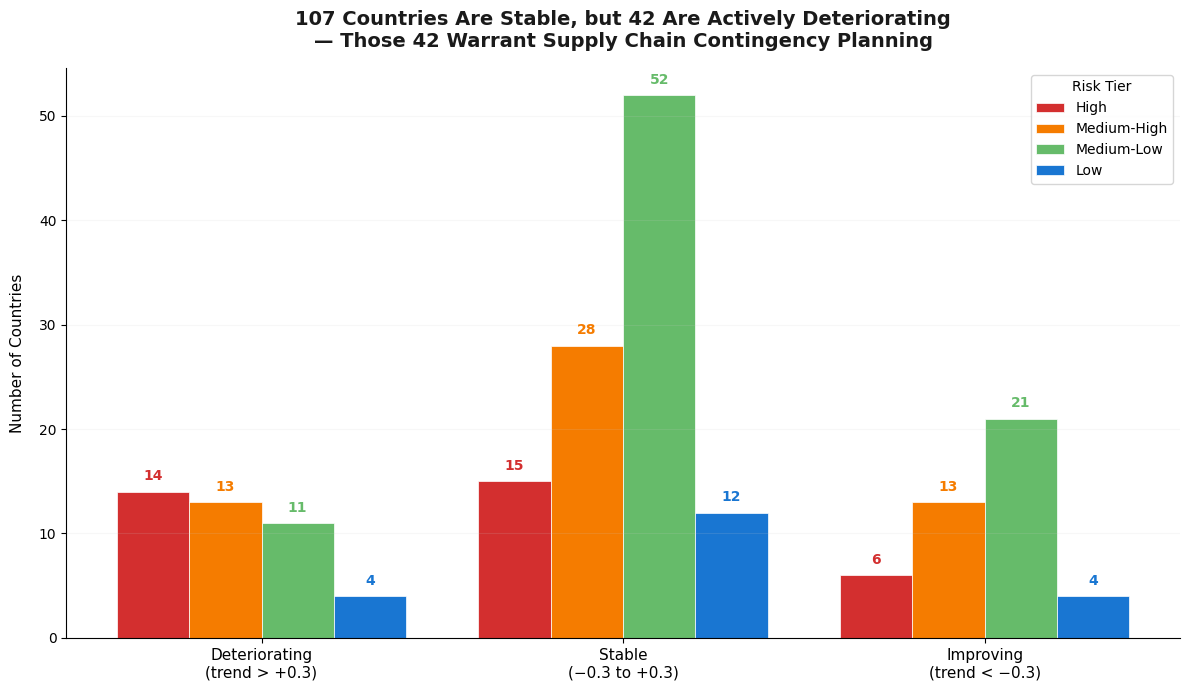

In [8]:
# Chart 6 — Risk Regime Distribution by Tier
# Cross-tab of risk tier (High/Medium/Low) against trajectory regime
# (improving, stable, deteriorating). The interesting finding is how many
# high-risk countries are also still deteriorating.

fig, ax = plt.subplots(figsize=(12, 7))

regime_order = ['deteriorating', 'stable', 'improving']
tier_order = ['High', 'Medium-High', 'Medium-Low', 'Low']
tier_colors = ['#D32F2F', '#F57C00', '#66BB6A', '#1976D2']

ct = pd.crosstab(latest['risk_regime'], latest['risk_tier'])
ct = ct.reindex(index=regime_order, columns=tier_order, fill_value=0)

x = np.arange(len(regime_order))
width = 0.2

for i, (tier, color) in enumerate(zip(tier_order, tier_colors)):
    bars = ax.bar(x + i * width - 0.3, ct[tier], width, label=tier,
                  color=color, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, ct[tier]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    str(val), ha='center', va='bottom', fontsize=10,
                    fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Deteriorating\n(trend > +0.3)', 'Stable\n(−0.3 to +0.3)',
                     'Improving\n(trend < −0.3)'], fontsize=11)
ax.set_ylabel('Number of Countries', fontsize=11, labelpad=10)
ax.set_title('107 Countries Are Stable, but 42 Are Actively Deteriorating\n'
             '— Those 42 Warrant Supply Chain Contingency Planning',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(title='Risk Tier', fontsize=10, title_fontsize=10, edgecolor='#ccc')
ax.grid(axis='y', alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

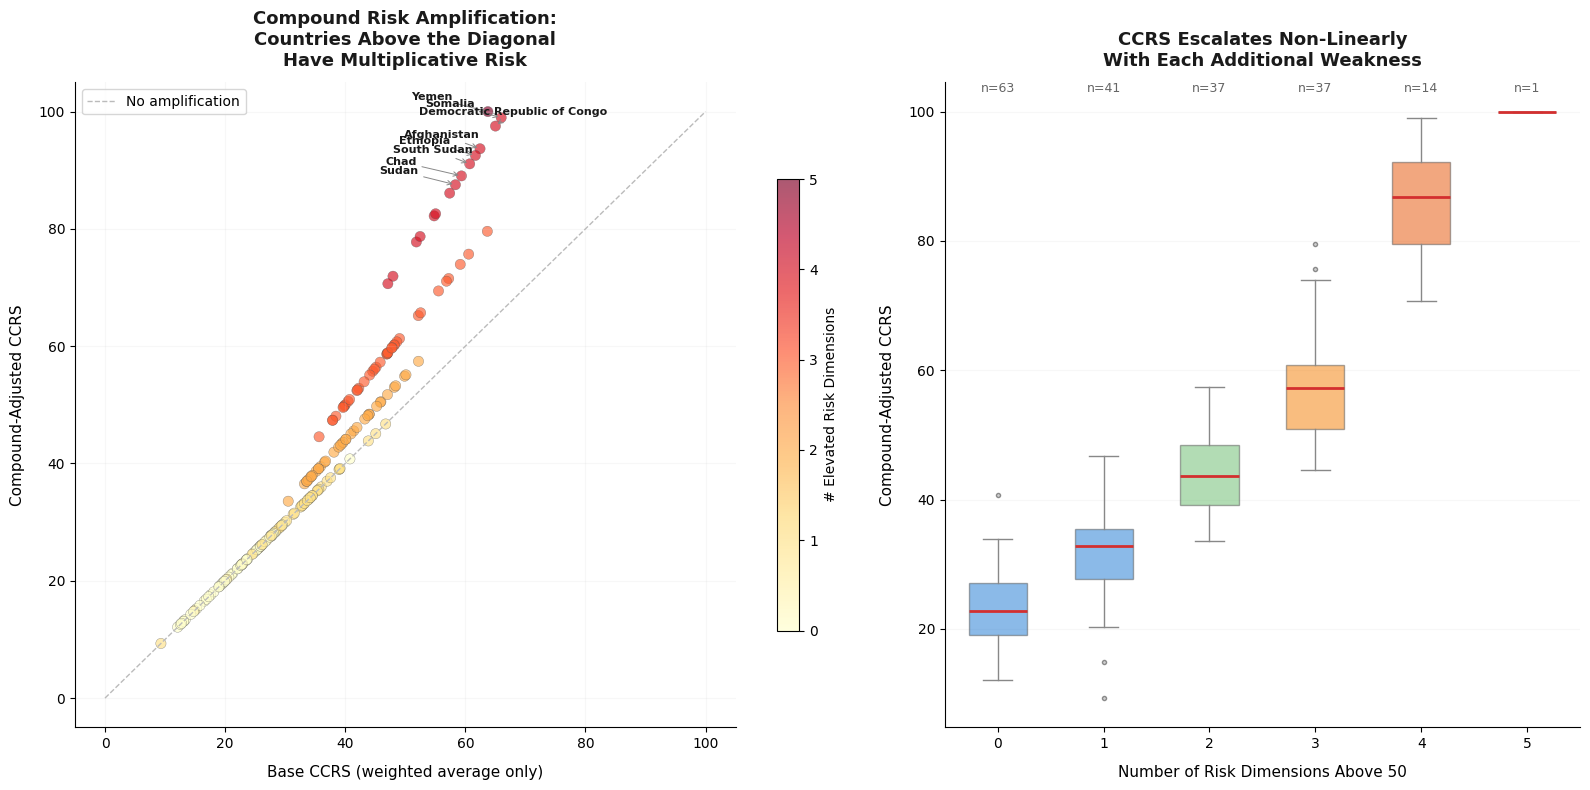

In [9]:
# Chart 7 — Compound Risk Amplification
# Left: scatter of CCRS vs CCRS_compound, coloured by number of elevated dimensions.
# Countries above the diagonal have been amplified by the compound multiplier.
# Right: boxplot shows the score distribution by compound tier.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),
                                gridspec_kw={'width_ratios': [1.3, 1]})

sc = ax1.scatter(latest['ccrs'], latest['ccrs_compound'],
                 c=latest[COL_DIMS_ELEVATED], cmap='YlOrRd',
                 s=55, alpha=0.65, edgecolors='#555', linewidth=0.3)

ax1.plot([0, 100], [0, 100], '--', color='#bbb', linewidth=1,
         label='No amplification')

amplified = latest[latest[COL_COMPOUND_MULT] > 1.2].nlargest(8, 'ccrs_compound')
for _, row in amplified.iterrows():
    off = (10, -10) if row['ccrs'] < 50 else (-55, 8)
    ax1.annotate(row['country'], xy=(row['ccrs'], row['ccrs_compound']),
                 xytext=off, textcoords='offset points',
                 fontsize=8, fontweight='bold', color='#1a1a1a',
                 arrowprops=dict(arrowstyle='->', color='#888', lw=0.7))

plt.colorbar(sc, ax=ax1, shrink=0.7, label='# Elevated Risk Dimensions')
ax1.set_xlabel('Base CCRS (weighted average only)', fontsize=11, labelpad=10)
ax1.set_ylabel('Compound-Adjusted CCRS', fontsize=11, labelpad=10)
ax1.set_title('Compound Risk Amplification:\nCountries Above the Diagonal\nHave Multiplicative Risk',
              fontsize=13, fontweight='bold', pad=12, color='#1a1a1a')
ax1.legend(loc='upper left', fontsize=10, edgecolor='#ccc')
ax1.grid(alpha=0.15, color='#ccc')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right panel: boxplots
dims_data = [latest[latest[COL_DIMS_ELEVATED] == n]['ccrs_compound']
             for n in range(6)]
bp = ax2.boxplot(dims_data, positions=range(6), widths=0.55, patch_artist=True,
                 medianprops=dict(color='#D32F2F', linewidth=2),
                 whiskerprops=dict(color='#888'), capprops=dict(color='#888'),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                 markerfacecolor='#888'))

box_colors = ['#1976D2', '#1976D2', '#66BB6A', '#F57C00', '#E65100', '#D32F2F']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor('#555')

for i in range(6):
    n = len(dims_data[i])
    if n > 0:
        ax2.text(i, 103, f'n={n}', ha='center', fontsize=9, color='#666')

ax2.set_xlabel('Number of Risk Dimensions Above 50', fontsize=11, labelpad=10)
ax2.set_ylabel('Compound-Adjusted CCRS', fontsize=11, labelpad=10)
ax2.set_title('CCRS Escalates Non-Linearly\nWith Each Additional Weakness',
              fontsize=13, fontweight='bold', pad=12, color='#1a1a1a')
ax2.grid(axis='y', alpha=0.15, color='#ccc')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

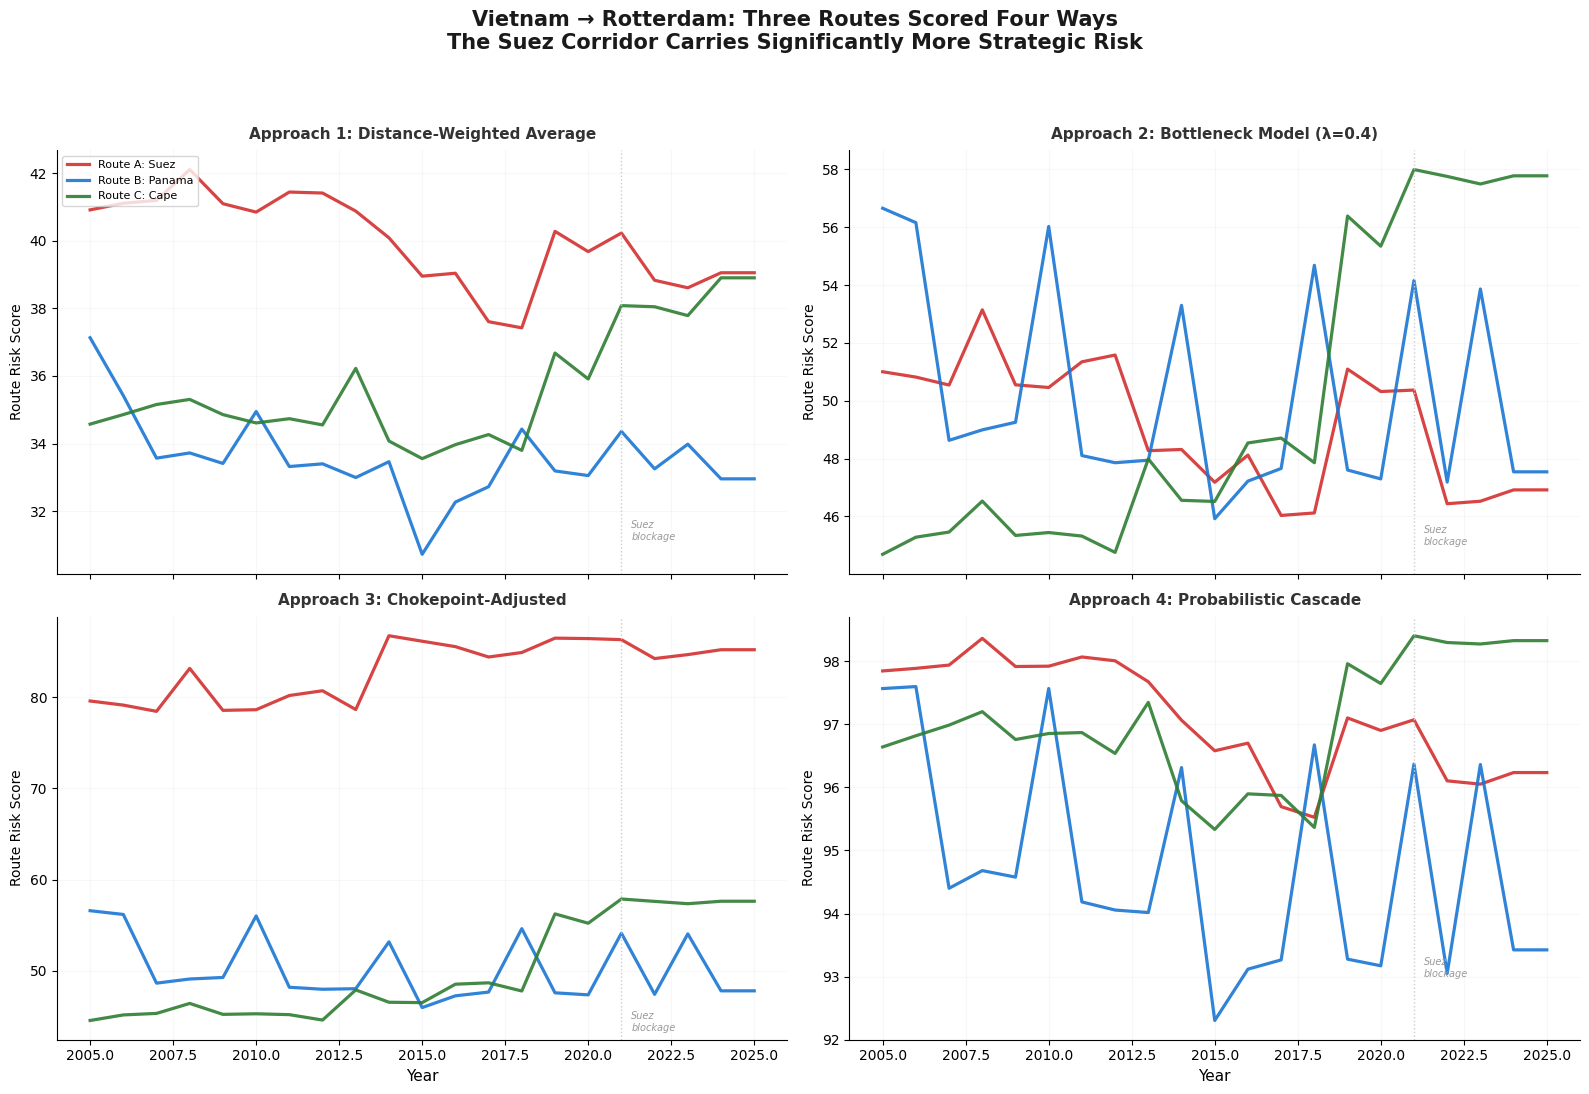

In [10]:
# Chart 8 — Route Risk: Vietnam to Rotterdam via Three Corridors
# Same three routes scored four different ways. The gap between approaches
# widens for the Suez corridor because Egypt and Djibouti score very differently
# under chokepoint-adjusted versus simple averaging.

ROUTES = {
    'Route A: Suez': {
        'countries': ['VNM', 'MYS', 'LKA', 'DJI', 'EGY', 'NLD'],
        'shares': [0.15, 0.10, 0.10, 0.15, 0.20, 0.30],
        'color': '#D32F2F',
    },
    'Route B: Panama': {
        'countries': ['VNM', 'PHL', 'USA', 'PAN', 'NLD'],
        'shares': [0.15, 0.10, 0.30, 0.15, 0.30],
        'color': '#1976D2',
    },
    'Route C: Cape': {
        'countries': ['VNM', 'MYS', 'LKA', 'MOZ', 'ZAF', 'NLD'],
        'shares': [0.10, 0.08, 0.08, 0.15, 0.24, 0.35],
        'color': '#2E7D32',
    },
}

def _get_score(df, iso3, year):
    """Safely get a country's ccrs_compound for a given year."""
    r = df[(df['iso3'] == iso3) & (df['year'] == year)]
    return r['ccrs_compound'].values[0] if len(r) else None

def route_simple_avg(countries, shares, df, year):
    scores = [_get_score(df, c, year) for c in countries]
    pairs = [(s, w) for s, w in zip(scores, shares) if s is not None]
    if not pairs:
        return None
    return sum(s * w for s, w in pairs) / sum(w for _, w in pairs)

def route_bottleneck(countries, shares, df, year, lam=0.4):
    scores = [_get_score(df, c, year) for c in countries]
    valid = [s for s in scores if s is not None]
    if not valid:
        return None
    avg = route_simple_avg(countries, shares, df, year)
    return lam * max(valid) + (1 - lam) * avg

def route_chokepoint(countries, shares, df, year, lam=0.4):
    weighted_scores = []
    total_weight = 0
    max_amplified = 0
    for iso3, share in zip(countries, shares):
        s = _get_score(df, iso3, year)
        if s is not None:
            mult = CHOKEPOINTS.get(iso3, 1.0)
            ew = share * mult
            weighted_scores.append(s * ew)
            total_weight += ew
            max_amplified = max(max_amplified, s * mult)
    if not weighted_scores:
        return None
    return lam * max_amplified + (1 - lam) * (sum(weighted_scores) / total_weight)

def route_probabilistic(countries, df, year):
    prob_fine = 1.0
    for iso3 in countries:
        s = _get_score(df, iso3, year)
        if s is not None:
            p = np.clip(s / 100, 0.01, 0.99)
            prob_fine *= (1 - p)
    return (1 - prob_fine) * 100

years = list(range(2005, wri['year'].max() + 1))
rd = {}
for rn, ri in ROUTES.items():
    rd[rn] = {
        'simple': [route_simple_avg(ri['countries'], ri['shares'], wri, y) for y in years],
        'bottleneck': [route_bottleneck(ri['countries'], ri['shares'], wri, y) for y in years],
        'chokepoint': [route_chokepoint(ri['countries'], ri['shares'], wri, y) for y in years],
        'probabilistic': [route_probabilistic(ri['countries'], wri, y) for y in years],
    }

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
fig.suptitle('Vietnam → Rotterdam: Three Routes Scored Four Ways\n'
             'The Suez Corridor Carries Significantly More Strategic Risk',
             fontsize=15, fontweight='bold', y=0.99, color='#1a1a1a')

method_titles = [
    ('simple', 'Approach 1: Distance-Weighted Average'),
    ('bottleneck', 'Approach 2: Bottleneck Model (λ=0.4)'),
    ('chokepoint', 'Approach 3: Chokepoint-Adjusted'),
    ('probabilistic', 'Approach 4: Probabilistic Cascade'),
]

for ax, (method, title) in zip(axes.flat, method_titles):
    for rn, ri in ROUTES.items():
        ax.plot(years, rd[rn][method], color=ri['color'],
                linewidth=2.3, label=rn, alpha=0.9)
    ax.axvline(2021, color='#ccc', linestyle=':', linewidth=1)
    ax.text(2021.3, ax.get_ylim()[0] + 1, 'Suez\nblockage',
            fontsize=7, color='#999', fontstyle='italic')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#333')
    ax.grid(alpha=0.15, color='#ccc')
    ax.set_ylabel('Route Risk Score', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1][0].set_xlabel('Year', fontsize=11)
axes[1][1].set_xlabel('Year', fontsize=11)
axes[0][0].legend(fontsize=8, edgecolor='#ccc', loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

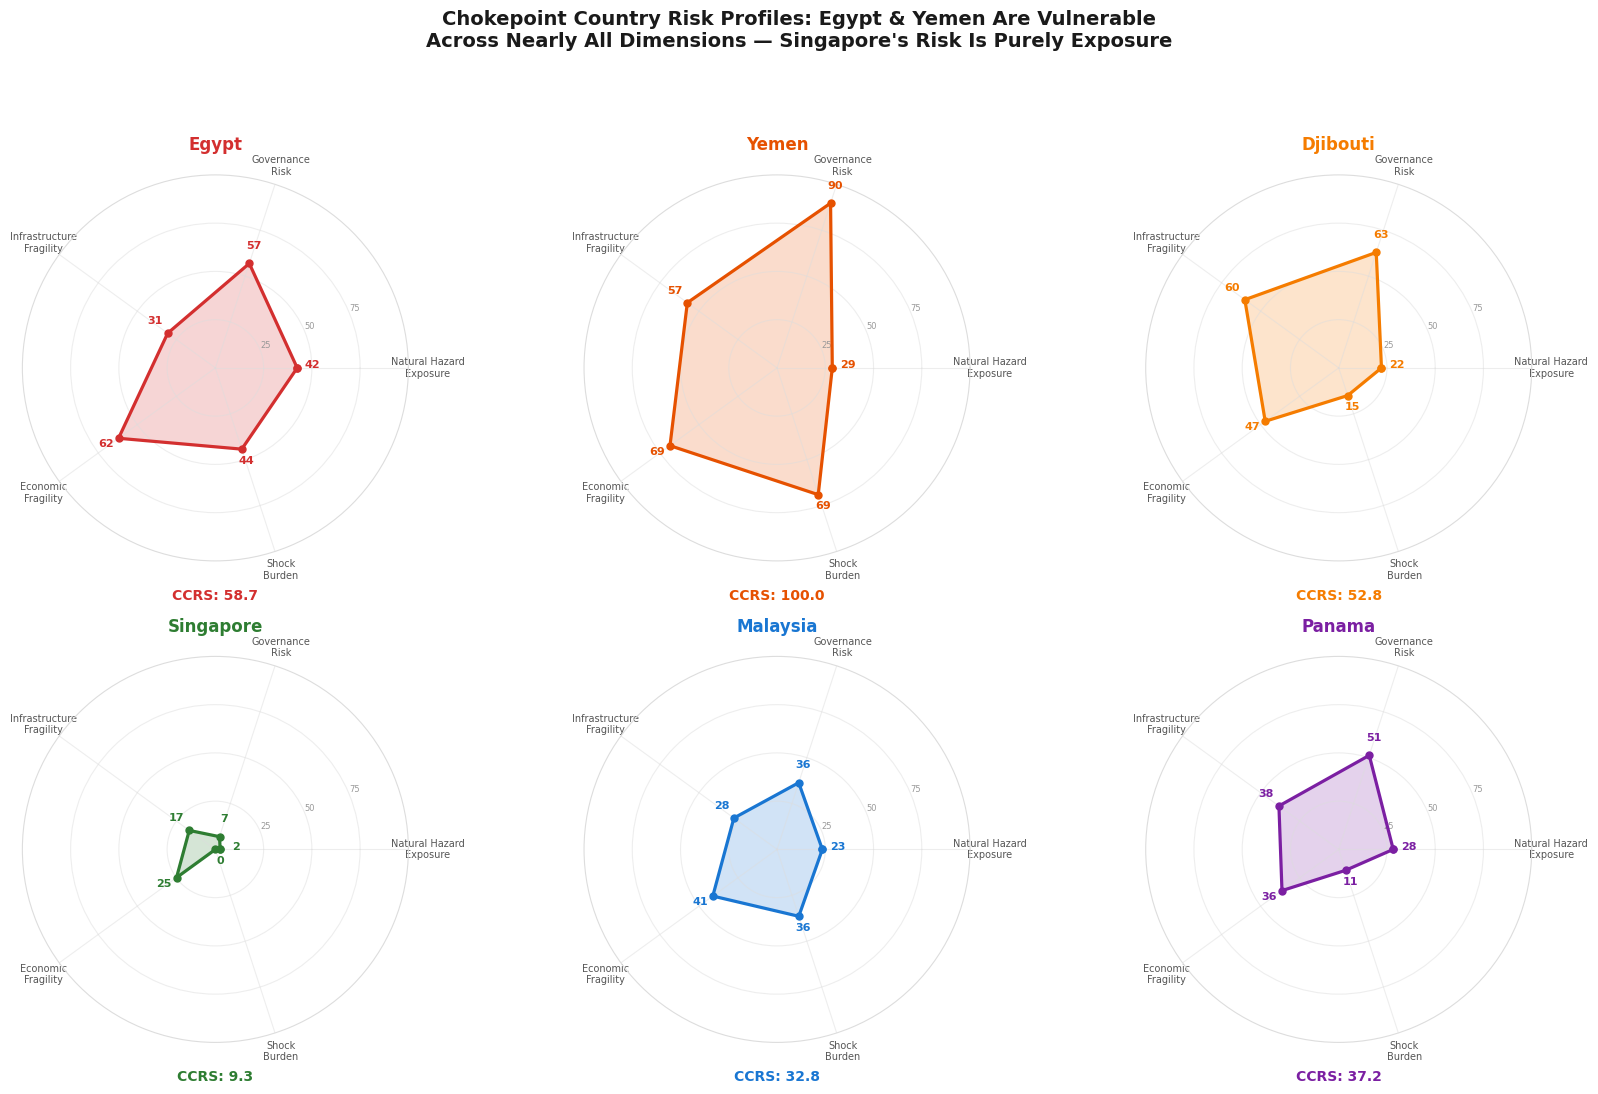

In [11]:
# Chart 9 — Risk Dimension Radar Profiles for Key Chokepoints
# Spider charts comparing Egypt, Yemen, Djibouti, Singapore, Malaysia, and Panama
# across all five fragility dimensions. Shows that high overall risk can come
# from very different underlying profiles.

chokepoint_countries = ['Egypt', 'Yemen', 'Djibouti', 'Singapore', 'Malaysia', 'Panama']
radar_feats = ['nhes', 'gss_risk', 'irs', 'efs', 'rsbs']
radar_labels = ['Natural Hazard\nExposure', 'Governance\nRisk',
                'Infrastructure\nFragility', 'Economic\nFragility', 'Shock\nBurden']
cp_colors = ['#D32F2F', '#E65100', '#F57C00', '#2E7D32', '#1976D2', '#7B1FA2']

angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(17, 11), subplot_kw=dict(projection='polar'))
fig.suptitle("Chokepoint Country Risk Profiles: Egypt & Yemen Are Vulnerable\n"
             "Across Nearly All Dimensions — Singapore's Risk Is Purely Exposure",
             fontsize=14, fontweight='bold', y=0.99, color='#1a1a1a')

for idx, (country, color) in enumerate(zip(chokepoint_countries, cp_colors)):
    ax = axes.flat[idx]
    row = latest[latest['country'] == country]
    if len(row):
        vals = row[radar_feats].values[0].tolist()
        vals += vals[:1]
        ax.fill(angles, vals, color=color, alpha=0.2)
        ax.plot(angles, vals, color=color, linewidth=2.3, marker='o', markersize=5)
        for a, v in zip(angles[:-1], vals[:-1]):
            ax.text(a, v + 8, f'{v:.0f}', fontsize=8, fontweight='bold',
                    color=color, ha='center')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7, color='#555')
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(['25', '50', '75'], fontsize=6, color='#999')
    ax.set_title(country, fontsize=12, fontweight='bold', color=color, pad=18)
    ax.grid(color='#ddd', alpha=0.5)
    ax.spines['polar'].set_color('#ddd')

    if len(row):
        ax.text(0.5, -0.10, f'CCRS: {row["ccrs_compound"].values[0]:.1f}',
                transform=ax.transAxes, fontsize=10, fontweight='bold',
                color=color, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

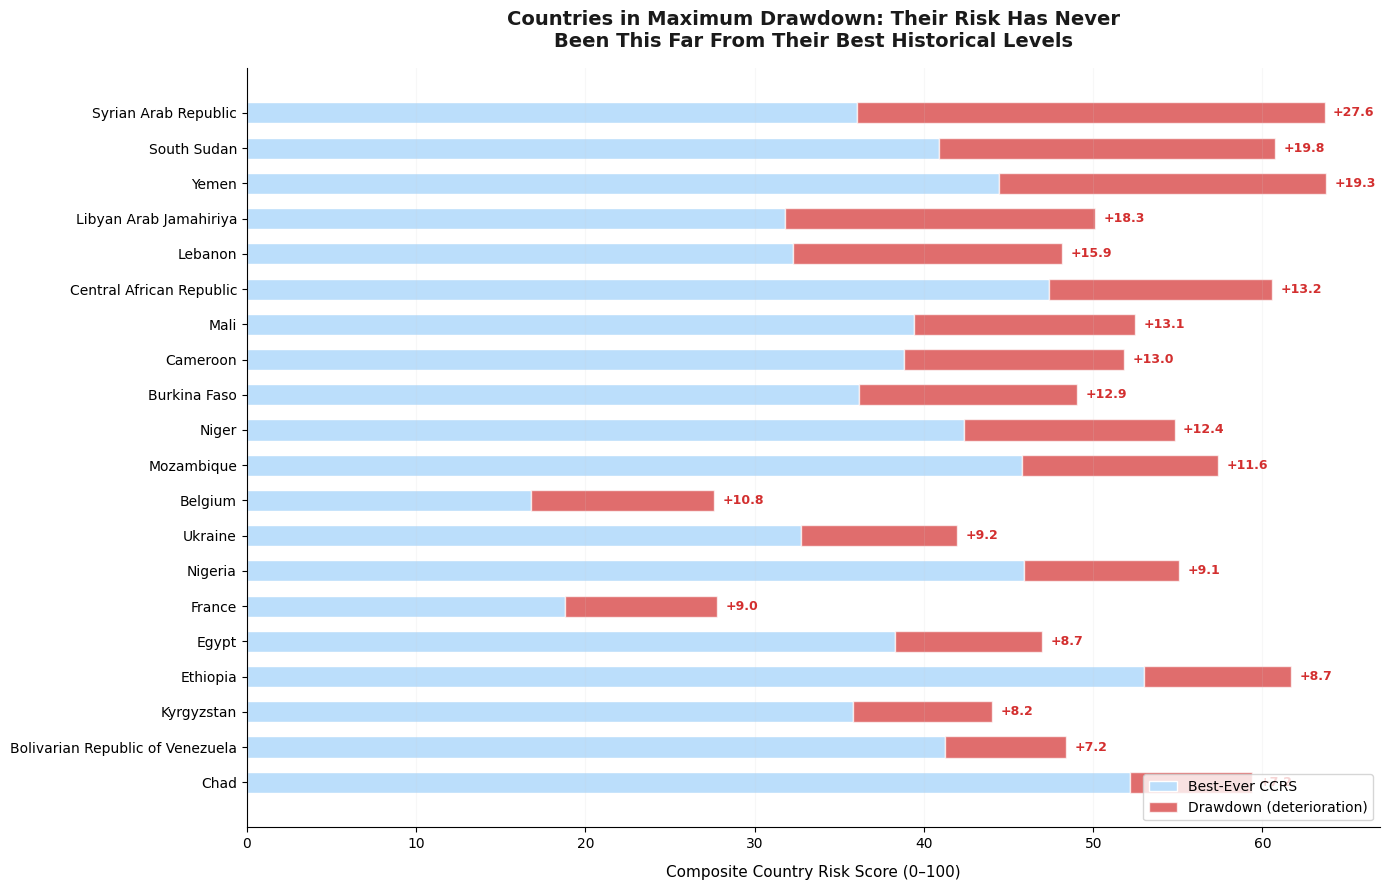

In [12]:
# Chart 10 — Drawdown Analysis
# Countries whose current CCRS is furthest from their best historical level.
# Stacked bars show baseline (best-ever score) + deterioration amount,
# making it easy to see both where a country sits now and how far it has fallen.

fig, ax = plt.subplots(figsize=(14, 9))

top_dd = latest.nlargest(20, 'ccrs_drawdown').sort_values('ccrs_drawdown')
y_pos = np.arange(len(top_dd))

for i, (_, row) in enumerate(top_dd.iterrows()):
    ax.barh(i, row['ccrs'] - row['ccrs_drawdown'], color='#BBDEFB', height=0.6,
            edgecolor='white', label='Best-Ever CCRS' if i == 0 else '')
    ax.barh(i, row['ccrs_drawdown'], left=row['ccrs'] - row['ccrs_drawdown'],
            color='#D32F2F', alpha=0.7, height=0.6, edgecolor='white',
            label='Drawdown (deterioration)' if i == 0 else '')
    ax.text(row['ccrs'] + 0.5, i, f'+{row["ccrs_drawdown"]:.1f}',
            fontsize=9, fontweight='bold', color='#D32F2F', va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_dd['country'], fontsize=10)
ax.set_xlabel('Composite Country Risk Score (0–100)', fontsize=11, labelpad=10)
ax.set_title('Countries in Maximum Drawdown: Their Risk Has Never\n'
             'Been This Far From Their Best Historical Levels',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(loc='lower right', fontsize=10, edgecolor='#ccc')
ax.grid(axis='x', alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

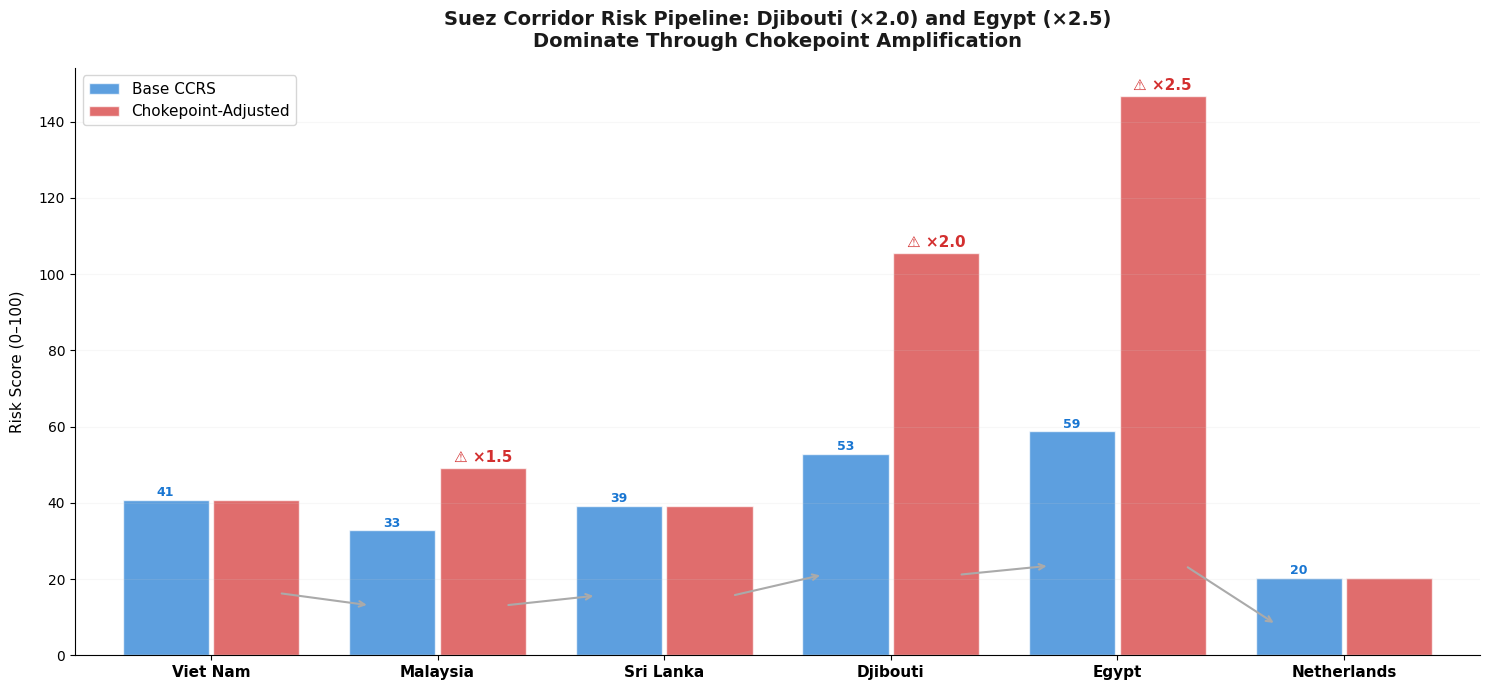

In [13]:

# Chart 11 — Route Pipeline: Chokepoint Amplification on the Suez Corridor
# Step-by-step bar chart tracing the Vietnam–Rotterdam Suez route segment by segment.
# The amplified bar shows each country's score after the chokepoint multiplier is applied.

fig, ax = plt.subplots(figsize=(15, 7))

route_isos = ['VNM', 'MYS', 'LKA', 'DJI', 'EGY', 'NLD']
rdata = []
for iso3 in route_isos:
    r = latest[latest['iso3'] == iso3]
    if len(r):
        score = r['ccrs_compound'].values[0]
        mult = CHOKEPOINTS.get(iso3, 1.0)
        rdata.append({'iso3': iso3, 'country': r['country'].values[0],
                       'base': score, 'mult': mult, 'effective': score * mult})

rdf = pd.DataFrame(rdata)
x_pos = np.arange(len(rdf))

ax.bar(x_pos - 0.2, rdf['base'], width=0.38, color='#1976D2', alpha=0.7,
       label='Base CCRS', edgecolor='white')
ax.bar(x_pos + 0.2, rdf['effective'], width=0.38, color='#D32F2F', alpha=0.7,
       label='Chokepoint-Adjusted', edgecolor='white')

for i, (_, row) in enumerate(rdf.iterrows()):
    if row['mult'] > 1.0:
        ax.text(i + 0.2, row['effective'] + 1.5, f'⚠ ×{row["mult"]:.1f}',
                fontsize=11, fontweight='bold', color='#D32F2F', ha='center')
    ax.text(i - 0.2, row['base'] + 1.0, f'{row["base"]:.0f}',
            fontsize=9, fontweight='bold', color='#1976D2', ha='center')

for i in range(len(rdf) - 1):
    ax.annotate('', xy=(i + 0.7, rdf.iloc[i + 1]['base'] * 0.4),
                xytext=(i + 0.3, rdf.iloc[i]['base'] * 0.4),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

ax.set_xticks(x_pos)
ax.set_xticklabels(rdf['country'], fontsize=11, fontweight='bold')
ax.set_ylabel('Risk Score (0–100)', fontsize=11, labelpad=10)
ax.set_title('Suez Corridor Risk Pipeline: Djibouti (×2.0) and Egypt (×2.5)\n'
             'Dominate Through Chokepoint Amplification',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(fontsize=11, edgecolor='#ccc', loc='upper left')
ax.grid(axis='y', alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.6, len(rdf) - 0.4)

plt.tight_layout()
plt.show()

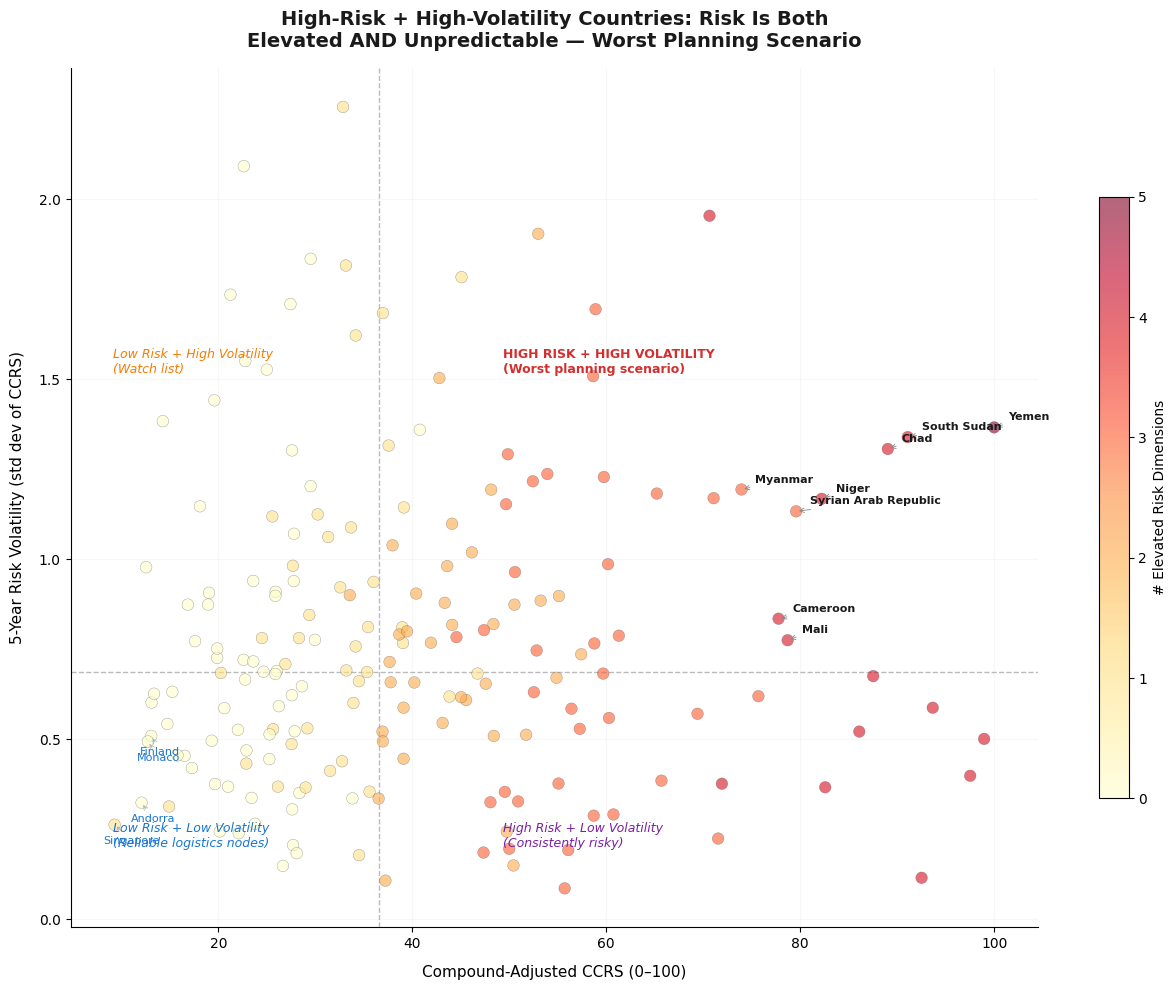

In [14]:
# Chart 12 — Risk Level vs Volatility
# Countries in the top-right quadrant (high level, high volatility) are the
# hardest to plan around — not just risky, but unpredictably risky.
# Quadrant boundaries at median level and median volatility.

fig, ax = plt.subplots(figsize=(13, 10))

vol_data = latest.dropna(subset=['ccrs_vol_5y']).copy()

sc = ax.scatter(vol_data['ccrs_compound'], vol_data['ccrs_vol_5y'],
                c=vol_data[COL_DIMS_ELEVATED], cmap='YlOrRd',
                s=70, alpha=0.6, edgecolors='#555', linewidth=0.3, zorder=3)

med_ccrs = vol_data['ccrs_compound'].median()
med_vol = vol_data['ccrs_vol_5y'].median()
ax.axvline(med_ccrs, color='#bbb', linestyle='--', linewidth=1)
ax.axhline(med_vol, color='#bbb', linestyle='--', linewidth=1)

ax.text(med_ccrs * 0.25, vol_data['ccrs_vol_5y'].quantile(0.93),
        'Low Risk + High Volatility\n(Watch list)',
        fontsize=9, color='#F57C00', fontstyle='italic')
ax.text(med_ccrs * 1.35, vol_data['ccrs_vol_5y'].quantile(0.93),
        'HIGH RISK + HIGH VOLATILITY\n(Worst planning scenario)',
        fontsize=9, color='#D32F2F', fontweight='bold')
ax.text(med_ccrs * 0.25, vol_data['ccrs_vol_5y'].quantile(0.05),
        'Low Risk + Low Volatility\n(Reliable logistics nodes)',
        fontsize=9, color='#1976D2', fontstyle='italic')
ax.text(med_ccrs * 1.35, vol_data['ccrs_vol_5y'].quantile(0.05),
        'High Risk + Low Volatility\n(Consistently risky)',
        fontsize=9, color='#7B1FA2', fontstyle='italic')

dz = vol_data[(vol_data['ccrs_compound'] > med_ccrs) &
              (vol_data['ccrs_vol_5y'] > med_vol)].nlargest(8, 'ccrs_compound')
for _, row in dz.iterrows():
    ax.annotate(row['country'], xy=(row['ccrs_compound'], row['ccrs_vol_5y']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=8, fontweight='bold', color='#1a1a1a',
                arrowprops=dict(arrowstyle='->', color='#888', lw=0.6))

sz = vol_data[(vol_data['ccrs_compound'] < 18) &
              (vol_data['ccrs_vol_5y'] < med_vol)].nsmallest(4, 'ccrs_compound')
for _, row in sz.iterrows():
    ax.annotate(row['country'], xy=(row['ccrs_compound'], row['ccrs_vol_5y']),
                xytext=(-8, -14), textcoords='offset points',
                fontsize=8, color='#1976D2',
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.5))

plt.colorbar(sc, ax=ax, shrink=0.7, label='# Elevated Risk Dimensions')
ax.set_xlabel('Compound-Adjusted CCRS (0–100)', fontsize=11, labelpad=10)
ax.set_ylabel('5-Year Risk Volatility (std dev of CCRS)', fontsize=11, labelpad=10)
ax.set_title('High-Risk + High-Volatility Countries: Risk Is Both\n'
             'Elevated AND Unpredictable — Worst Planning Scenario',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.grid(alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

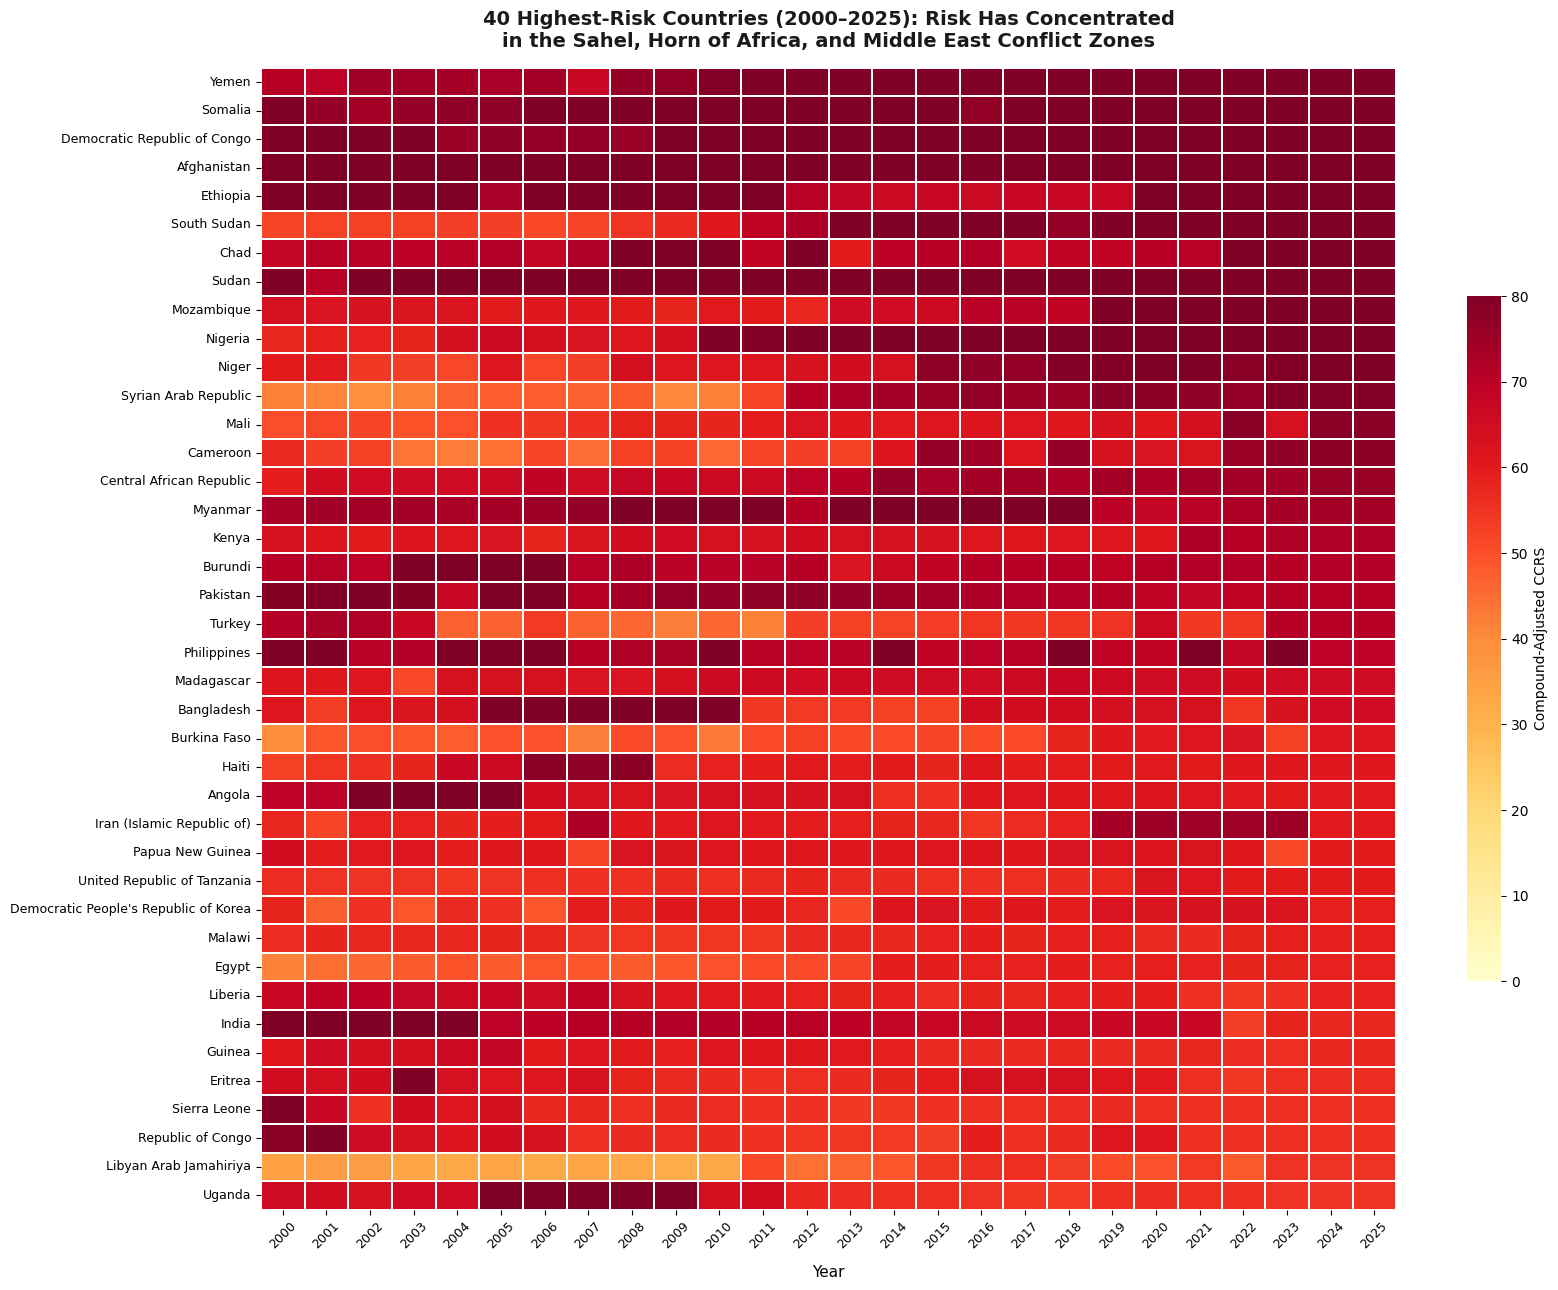

In [15]:
# Chart 13 — Global Risk Heatmap: Top 40 Countries Over Time
# Each row is a country, each column a year. Sorted by most recent CCRS score.
# Makes multi-decade trajectories and crisis-year spikes immediately visible.

fig, ax = plt.subplots(figsize=(17, 13))

top40 = latest.nlargest(40, 'ccrs_compound')['country'].tolist()
heat = wri[wri['country'].isin(top40)].pivot_table(
    index='country', columns='year', values='ccrs_compound'
)
max_year = wri['year'].max()
heat = heat.loc[heat[max_year].sort_values(ascending=False).index]

sns.heatmap(heat, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Compound-Adjusted CCRS', 'shrink': 0.6},
            ax=ax, vmin=0, vmax=80)

ax.set_title('40 Highest-Risk Countries (2000–2025): Risk Has Concentrated\n'
             'in the Sahel, Horn of Africa, and Middle East Conflict Zones',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, rotation=45)

plt.tight_layout()
plt.show()


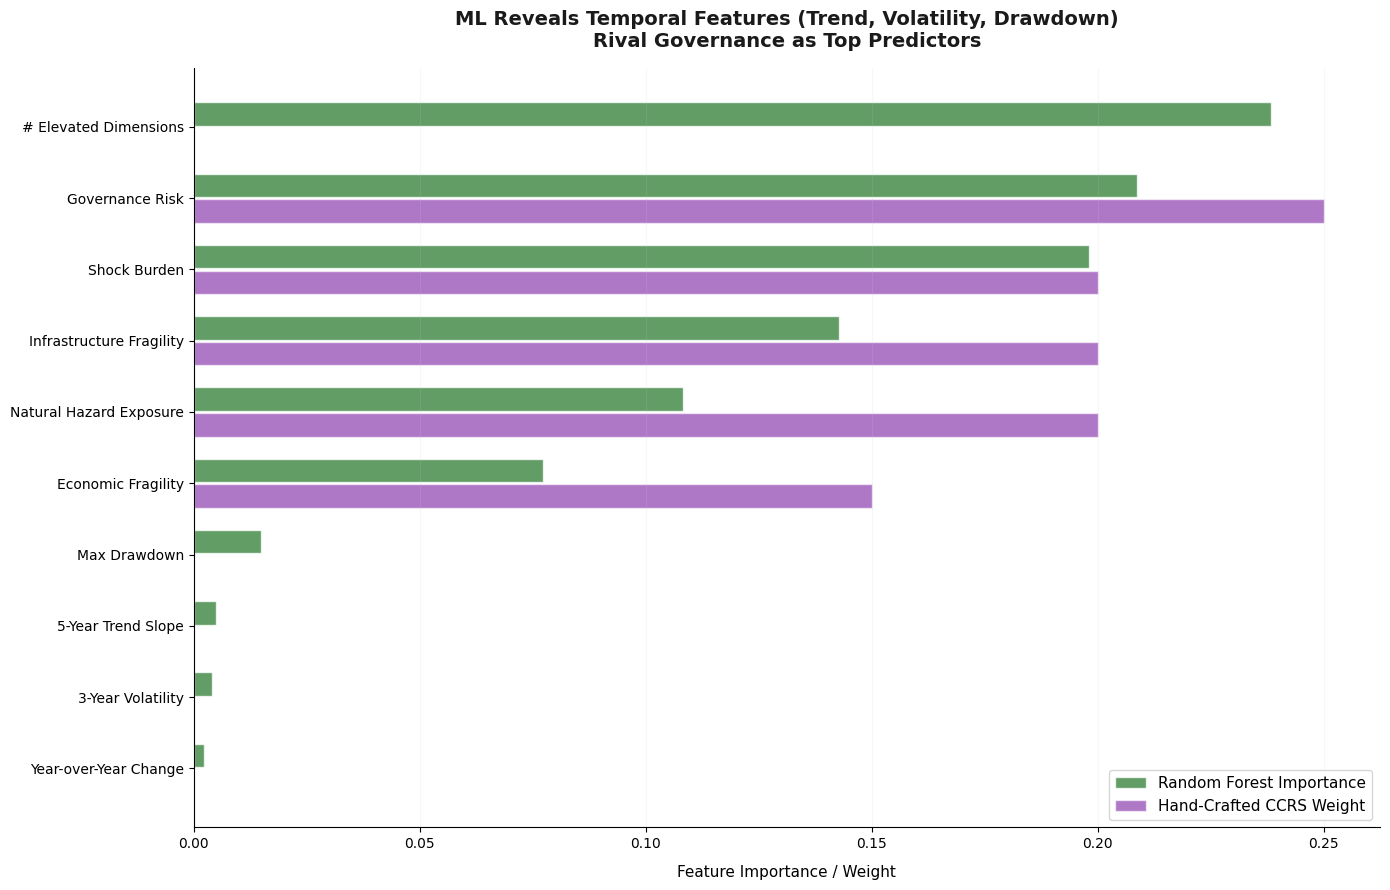

In [16]:
# Chart 14 — Feature Importance: Manual Weights vs Random Forest
# Side-by-side comparison of the CCRS_WEIGHTS assigned in feature engineering
# versus what a Random Forest independently identifies as most predictive.
# Strong agreement validates the weight design; divergence flags dimensions
# that may be under- or over-weighted.

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

ML_FEATURES = ['nhes', 'gss_risk', 'irs', 'efs', 'rsbs', 'ccrs_yoy',
               'ccrs_vol_3y', 'ccrs_trend_5y', 'ccrs_drawdown',
               COL_DIMS_ELEVATED]

ml_data = wri.dropna(subset=ML_FEATURES).copy()
X = ml_data[ML_FEATURES]
le = LabelEncoder()
y = le.fit_transform(ml_data['risk_tier'])

train_mask = ml_data['year'] < 2022
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             class_weight='balanced', random_state=42)
rf.fit(X[train_mask], y[train_mask])

imp = pd.DataFrame({'feature': ML_FEATURES, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=True)

hand = {'nhes': 0.20, 'gss_risk': 0.25, 'irs': 0.20, 'efs': 0.15, 'rsbs': 0.20,
        'ccrs_yoy': 0, 'ccrs_vol_3y': 0, 'ccrs_trend_5y': 0,
        'ccrs_drawdown': 0, COL_DIMS_ELEVATED: 0}
imp['hand_weight'] = imp['feature'].map(hand)

readable = {
    'nhes': 'Natural Hazard Exposure', 'gss_risk': 'Governance Risk',
    'irs': 'Infrastructure Fragility', 'efs': 'Economic Fragility',
    'rsbs': 'Shock Burden', 'ccrs_yoy': 'Year-over-Year Change',
    'ccrs_vol_3y': '3-Year Volatility', 'ccrs_trend_5y': '5-Year Trend Slope',
    'ccrs_drawdown': 'Max Drawdown', COL_DIMS_ELEVATED: '# Elevated Dimensions',
}

fig, ax = plt.subplots(figsize=(14, 9))
y_pos = np.arange(len(imp))

ax.barh(y_pos + 0.18, imp['importance'], height=0.33, color='#2E7D32',
        alpha=0.75, label='Random Forest Importance', edgecolor='white')
ax.barh(y_pos - 0.18, imp['hand_weight'], height=0.33, color='#7B1FA2',
        alpha=0.6, label='Hand-Crafted CCRS Weight', edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels([readable.get(f, f) for f in imp['feature']], fontsize=10)
ax.set_xlabel('Feature Importance / Weight', fontsize=11, labelpad=10)
ax.set_title('ML Reveals Temporal Features (Trend, Volatility, Drawdown)\n'
             'Rival Governance as Top Predictors',
             fontsize=14, fontweight='bold', pad=15, color='#1a1a1a')
ax.legend(fontsize=11, edgecolor='#ccc', loc='lower right')
ax.grid(axis='x', alpha=0.15, color='#ccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()